In [1]:
# Cell 1 — Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120


os.makedirs('charts', exist_ok=True)
print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv('Churn_Modelling.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 10000 rows × 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Cell 3 — Dataset Shape, Info & Descriptive Statistics
print('── Shape ──────────────────────────────')
print(df.shape)

print('\n── Data Types & Non-Null Counts ────────')
df.info()

print('\n── Descriptive Statistics ──────────────')
df.describe()

── Shape ──────────────────────────────
(10000, 14)

── Data Types & Non-Null Counts ────────
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB

── Descriptive

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
# Cell 4 — Check Missing Values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing >= 0].to_string())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

Total missing values: 0


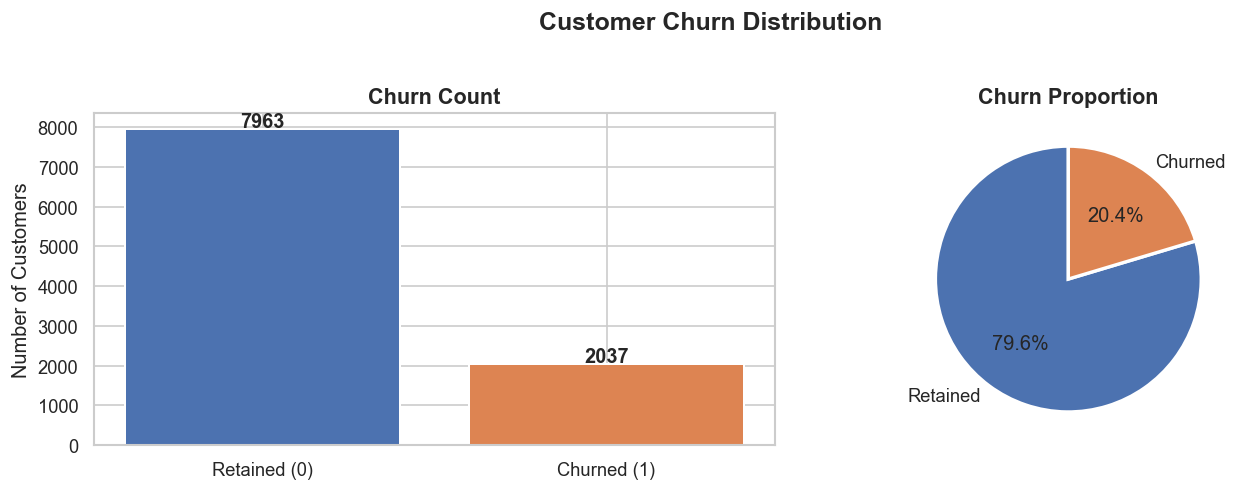

In [5]:
# Cell 5 — Visualize Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Exited'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

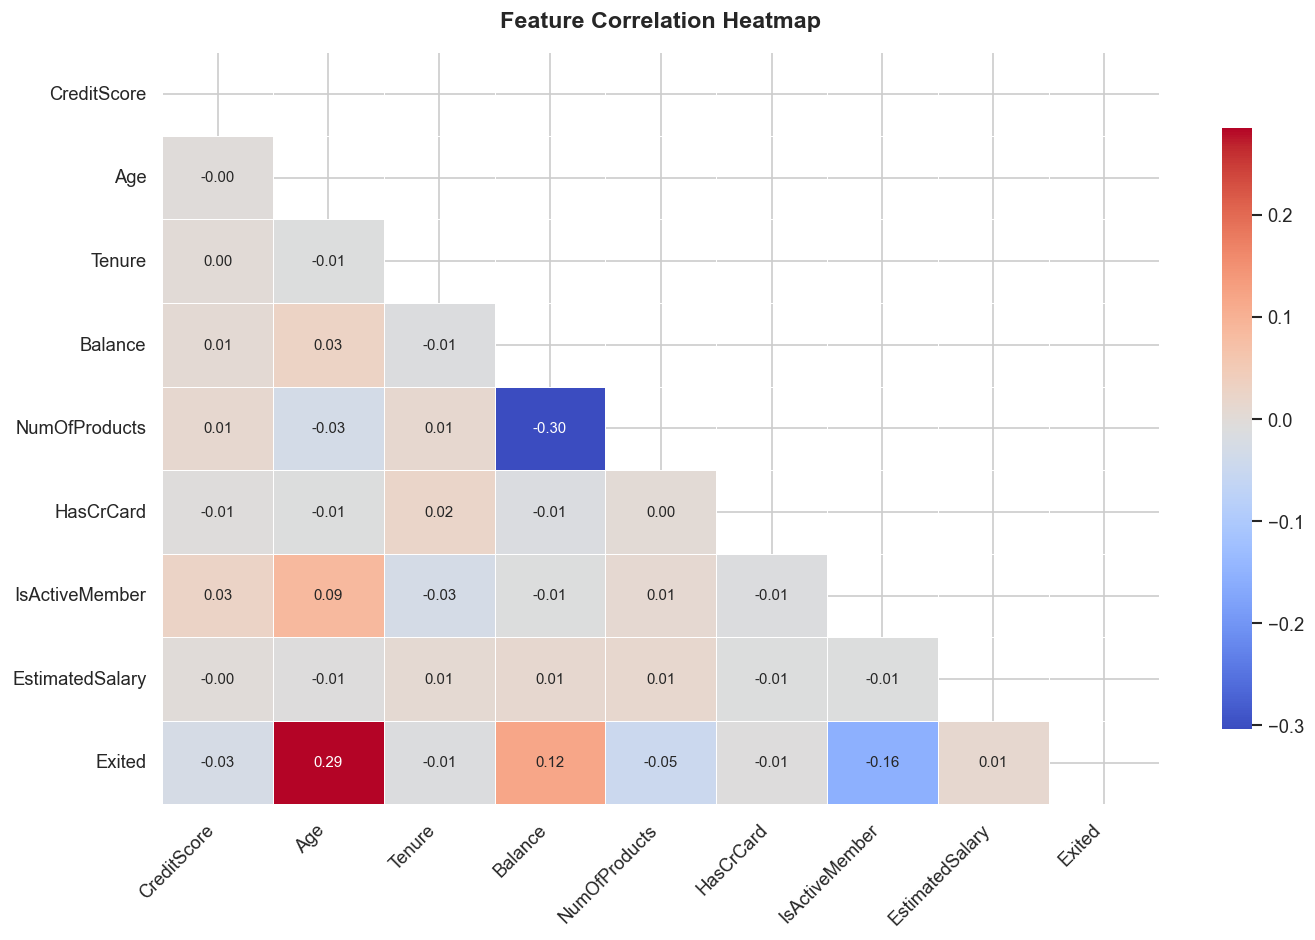

In [6]:
# Cell 6 — Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['RowNumber', 'CustomerId'])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [7]:
# Cell 7 — Data Preprocessing

# 7a. Drop irrelevant columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print('Dropped: RowNumber, CustomerId, Surname')

# 7b. Label Encode Gender
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Female=0, Male=1
print('Label encoded: Gender (Female=0, Male=1)')

# 7c. One-Hot Encode Geography
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)
print(f'One-hot encoded: Geography → {[c for c in df_clean.columns if "Geography" in c]}')

print(f'\nFinal shape after preprocessing: {df_clean.shape}')
df_clean.head()

Dropped: RowNumber, CustomerId, Surname
Label encoded: Gender (Female=0, Male=1)
One-hot encoded: Geography → ['Geography_Germany', 'Geography_Spain']

Final shape after preprocessing: (10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [8]:
# Cell 8 — Feature / Target Split & Train-Test Split
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Features     : {X_train.shape[1]}')

Training set : 8000 samples
Test set     : 2000 samples
Features     : 11


In [9]:
# Cell 9 — Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied: fitted on training set, transformed both sets.')

StandardScaler applied: fitted on training set, transformed both sets.


In [10]:
# Cell 10 — Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)')

Logistic Regression Accuracy: 0.8080 (80.80%)


In [11]:
# Cell 11 — Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
rf_acc   = accuracy_score(y_test, rf_preds)

print(f'Random Forest Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')

Random Forest Accuracy: 0.8680 (86.80%)


══════════════════════════════════════════
       LOGISTIC REGRESSION EVALUATION     
══════════════════════════════════════════
Accuracy : 0.8080

Confusion Matrix:
[[1540   53]
 [ 331   76]]

Classification Report:
              precision    recall  f1-score   support

    Retained       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



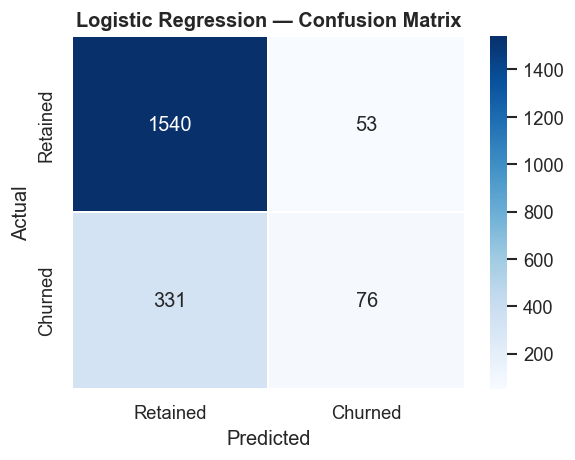

In [12]:
# Cell 12 — Model Evaluation: Logistic Regression
print('══════════════════════════════════════════')
print('       LOGISTIC REGRESSION EVALUATION     ')
print('══════════════════════════════════════════')
print(f'Accuracy : {lr_acc:.4f}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, lr_preds))
print('\nClassification Report:')
print(classification_report(y_test, lr_preds, target_names=['Retained', 'Churned']))

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, linecolor='white')
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('charts/lr_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

══════════════════════════════════════════
       RANDOM FOREST EVALUATION           
══════════════════════════════════════════
Accuracy : 0.8680

Confusion Matrix:
[[1554   39]
 [ 225  182]]

Classification Report:
              precision    recall  f1-score   support

    Retained       0.87      0.98      0.92      1593
     Churned       0.82      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



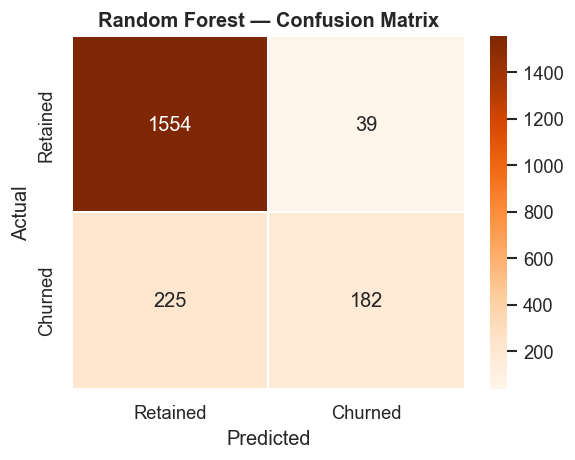

In [13]:
# Cell 13 — Model Evaluation: Random Forest
print('══════════════════════════════════════════')
print('       RANDOM FOREST EVALUATION           ')
print('══════════════════════════════════════════')
print(f'Accuracy : {rf_acc:.4f}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, rf_preds))
print('\nClassification Report:')
print(classification_report(y_test, rf_preds, target_names=['Retained', 'Churned']))

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            linewidths=1, linecolor='white')
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('charts/rf_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
# Cell 14 — Model Comparison Summary
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [round(lr_acc, 4), round(rf_acc, 4)]
})
comparison['Accuracy (%)'] = (comparison['Accuracy'] * 100).round(2)
print(comparison.to_string(index=False))

best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Model']
print(f'\n✅ Best performing model: {best_model}')

              Model  Accuracy  Accuracy (%)
Logistic Regression     0.808          80.8
      Random Forest     0.868          86.8

✅ Best performing model: Random Forest


In [15]:
# Cell 15 — Feature Importance Table (Random Forest)
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feat_df['Importance (%)'] = (feat_df['Importance'] * 100).round(2)
print('Feature Importance — Random Forest:')
print(feat_df.to_string(index=False))

Feature Importance — Random Forest:
          Feature  Importance  Importance (%)
              Age    0.312656           31.27
    NumOfProducts    0.217896           21.79
          Balance    0.110807           11.08
      CreditScore    0.082858            8.29
  EstimatedSalary    0.081319            8.13
   IsActiveMember    0.066220            6.62
Geography_Germany    0.047563            4.76
           Tenure    0.043506            4.35
           Gender    0.017778            1.78
        HasCrCard    0.010782            1.08
  Geography_Spain    0.008615            0.86


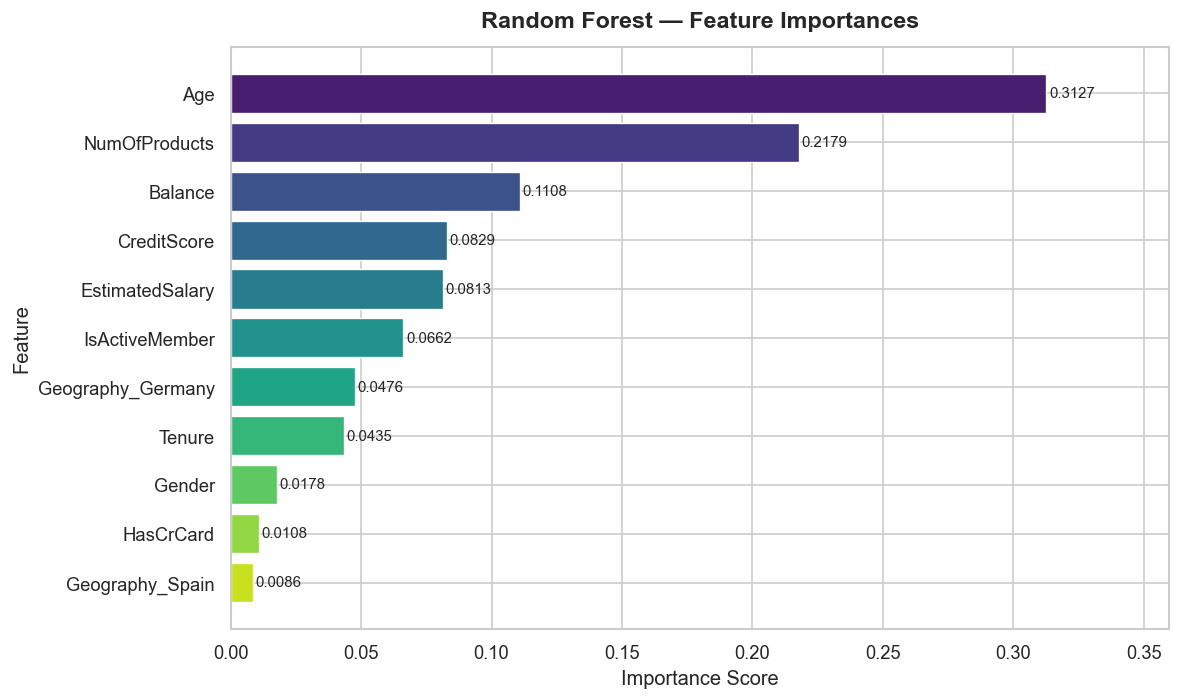

In [16]:
# Cell 16 — Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', len(feat_df))
bars = plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
                color=colors[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, feat_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.xlim(0, feat_df['Importance'].max() * 1.15)
plt.tight_layout()
plt.savefig('charts/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [17]:
# Cell 17 — Final Conclusion
top_n = 5
top_features = feat_df.head(top_n)

print('=' * 55)
print('        CUSTOMER CHURN PREDICTION — SUMMARY        ')
print('=' * 55)

print(f"""
DATASET
  • Total records  : {df.shape[0]:,}
  • Features used  : {X.shape[1]}
  • Churn rate     : {y.mean()*100:.1f}%

MODEL PERFORMANCE
  • Logistic Regression  Accuracy : {lr_acc*100:.2f}%
  • Random Forest        Accuracy : {rf_acc*100:.2f}%  ← Best

TOP {top_n} FEATURES DRIVING CHURN (Random Forest):""")

for rank, row in enumerate(top_features.itertuples(), start=1):
    print(f'  {rank}. {row.Feature:<25} {row._3:.2f}%')

print("""
KEY INSIGHTS
  • Age is typically the strongest predictor — older
    customers churn more frequently.
  • NumOfProducts and IsActiveMember are strong
    behavioral indicators of retention.
  • Balance and EstimatedSalary reflect financial
    engagement with the bank.
  • Geography (Germany) shows notably higher churn rates.

RECOMMENDATION
  Random Forest outperforms Logistic Regression on this
  dataset. Focus retention campaigns on older, inactive
  customers — especially those in Germany with single
  products and high balances.
""")
print('=' * 55)

        CUSTOMER CHURN PREDICTION — SUMMARY        

DATASET
  • Total records  : 10,000
  • Features used  : 11
  • Churn rate     : 20.4%

MODEL PERFORMANCE
  • Logistic Regression  Accuracy : 80.80%
  • Random Forest        Accuracy : 86.80%  ← Best

TOP 5 FEATURES DRIVING CHURN (Random Forest):
  1. Age                       31.27%
  2. NumOfProducts             21.79%
  3. Balance                   11.08%
  4. CreditScore               8.29%
  5. EstimatedSalary           8.13%

KEY INSIGHTS
  • Age is typically the strongest predictor — older
    customers churn more frequently.
  • NumOfProducts and IsActiveMember are strong
    behavioral indicators of retention.
  • Balance and EstimatedSalary reflect financial
    engagement with the bank.
  • Geography (Germany) shows notably higher churn rates.

RECOMMENDATION
  Random Forest outperforms Logistic Regression on this
  dataset. Focus retention campaigns on older, inactive
  customers — especially those in Germany with single
